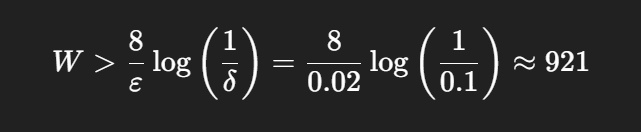

In [ ]:
# 8/0.02
np.log()

In [1]:
import gurobipy as gp
import pandas as pd
import numpy as np
from collections import defaultdict
from scipy.stats import multivariate_normal
from tqdm import tqdm
import matplotlib.pyplot as plt
from dataclasses import dataclass

In [2]:
@dataclass
class Bus:
    def __init__(self, bus_id, pd, gs, gens):
        self.bus_id = bus_id
        self.pd = pd
        self.gs = gs
        self.gens = gens
    def __repr__(self):
        return (f"Bus(pd={self.pd}, gs={self.gs}, gens={self.gens})")
        
@dataclass
class Gen:
    def __init__(self, bus, gen_id, pmin, pmax, pstart, cost):
        self.bus = bus
        self.gen_id = gen_id
        self.pmin = pmin
        self.pmax = pmax
        self.pstart = pstart
        self.cost = cost
    def __repr__(self):
        return (f"Generator(bus={self.bus}, pmin={self.pmin}, pmax={self.pmax}, "
                f"pstart={self.pstart}, cost={self.cost})")

@dataclass
class Line:
    def __init__(self, line_id, rate, frombus, tobus, one_over_reactance):
        self.line_id = line_id
        self.rate = rate
        self.frombus = frombus
        self.tobus = tobus
        self.one_over_reactance = one_over_reactance # β beta
    def __repr__(self):
        return (f"TransmissionLine(rate={self.rate}, frombus={self.frombus}, "
                f"tobus={self.tobus}, one_over_reactance={self.one_over_reactance})")
@dataclass
class NetworkReference:
    def __init__(self, ref, bus, bus_indices, gen, gen_indices, line, line_indices, B, pi, stdomega):
        self.ref = ref # Dictionary of ref data
        self.bus = bus # list of bus
        self.bus_indices = bus_indices
        self.gen = gen
        self.gen_indices = gen_indices
        self.line = line 
        self.line_indices = line_indices
        self.B = B  # Admittance matrix
        self.pi = pi  # π Inverse reduced admittance matrix
        self.stdomega = stdomega  # stdω List of standard deviations
    
@dataclass
class OPFScenarios:
    def __init__(self,noptimal, ref, scenarios, solutions, cbases, rbases, whichbasis, whichscenario):
        self.noptimal = noptimal
        self.ref = ref
        self.scenarios = scenarios
        self.solutions = solutions
        self.cbases = cbases
        self.rbases = rbases
        self.whichbasis = whichbasis
        self.whichscenario = whichscenario

@dataclass
class SingleScenarioOPF:
    def __init__(self, model, p, omega):
        self.model = model
        self.p = p
        self.omega = omega

In [4]:

def networkreference(data_file, sigma_scaling=0.05):
    ref = pd.read_excel(data_file, sheet_name=['baseMVA', 'bus','gen','gencost','branch'])
    ref['baseMVA'] = ref['baseMVA'][0].values[0]
    ref['gen'] =  ref['gen'][ref['gen']['status'] == 1]
    ref['gencost'] = ref['gencost'][ref['gencost']["gen_ID"].isin(ref['gen']["gen_ID"].tolist())]
    
    bus_gens = ref["gen"].groupby("bus_i")["gen_ID"].unique().to_dict()
    
    for b in ref["bus"]["bus_i"]:
        if b not in bus_gens:
            bus_gens[b]=[]
            
    scale_factors = np.array([ref['baseMVA']**2, ref['baseMVA'], 1])
    
    gen = {ref['gen'].loc[i,"gen_ID"]: Gen(
                ref['gen'].loc[i,"bus_i"],
                ref['gen'].loc[i,"gen_ID"],
                ref['gen'].loc[i,"Pmin"]/ref['baseMVA'],
                ref['gen'].loc[i,"Pmax"]/ref['baseMVA'],
                ref['gen'].loc[i,"Pg"]/ref['baseMVA'],
                np.array(ref['gencost'].loc[i,['c2','c1','c0']])*scale_factors
            ) for i in ref['gen'].index}
          
    
    bus = {ref['bus'].loc[i,"bus_i"]: Bus(
            ref['bus'].loc[i,"bus_i"],
            ref['bus'].loc[i,"Pd"]/ref['baseMVA'],
            ref['bus'].loc[i,"Gs"]/ref['baseMVA'],
            bus_gens[ref['bus'].loc[i,"bus_i"]],
            ) for i in ref['bus'].index}
          
    
    line = {ref['branch'].loc[l,"line_ID"]: Line(
            l+1, # need line index starts from 1, l in ref['branch'].index starts from 0
            ref['branch'].loc[l,"rateA"]/ref['baseMVA'],
            ref['branch'].loc[l,"bus_i"],
            ref['branch'].loc[l,"bus_j"],
            1/ ref['branch'].loc[l,"x"]
            ) for l in ref['branch'].index
            }
           
    
    ref['ref_buses'] = ref['bus'][ref['bus'].type==3]
    
    B = admittancematrix(ref)
    bus_IDs = sorted(ref['bus']["bus_i"].tolist())
    bus_IDs_Index = {b:i for i,b in enumerate(bus_IDs)}
    B_mat = np.zeros((len(bus_IDs),len(bus_IDs)))
    for b1 in bus_IDs:
        for b2 in bus_IDs:
            B_mat[bus_IDs_Index[b1],bus_IDs_Index[b2]] = B[b1,b2]
    B_red = remove_rows_and_columns(B_mat, 
                                    bus_IDs_Index[ref['ref_buses']["bus_i"].values[0]], 
                                    bus_IDs_Index[ref['ref_buses']["bus_i"].values[0]])
    
    pi_mat = np.linalg.inv(B_red)
    
    pi_mat = add_row_and_column(pi_mat, 
                            bus_IDs_Index[ref['ref_buses']["bus_i"].values[0]], 
                            bus_IDs_Index[ref['ref_buses']["bus_i"].values[0]])
    pi = defaultdict(float)
    for b1 in bus_IDs:
        for b2 in bus_IDs:
            pi[b1,b2]=pi_mat[bus_IDs_Index[b1],bus_IDs_Index[b2]] 
    
    stdomega = [sigma_scaling*(ref['bus'].loc[b,"Pd"]/ref['baseMVA']) for b in ref['bus'].index]
    bus_indices = [i for i in ref['bus']['bus_i']]
    gen_indices = [i for i in ref['gen']['gen_ID']]
    line_indices = [i for i in ref['branch']['line_ID']]

    return NetworkReference(ref,bus, bus_indices,gen,gen_indices,line,line_indices,B,pi,stdomega)

def admittancematrix(ref):
    nbus = len(ref['bus'])
    B = defaultdict(float)
    for br in ref['branch'].index:
        f_bus = ref['branch'].loc[br,"bus_i"]
        t_bus = ref['branch'].loc[br,"bus_j"]
        B[f_bus, t_bus] += (-ref['branch'].loc[br,"x"]/(ref['branch'].loc[br,"x"]**2+ref['branch'].loc[br,"r"]**2)) # imaginary part of admittance, x/(x^2+r^2)
        B[t_bus, f_bus] += (-ref['branch'].loc[br,"x"]/(ref['branch'].loc[br,"x"]**2+ref['branch'].loc[br,"r"]**2)) 
        B[f_bus, f_bus] += (ref['branch'].loc[br,"x"]/(ref['branch'].loc[br,"x"]**2+ref['branch'].loc[br,"r"]**2))
        B[t_bus, t_bus] += (ref['branch'].loc[br,"x"]/(ref['branch'].loc[br,"x"]**2+ref['branch'].loc[br,"r"]**2))
    return B

def remove_rows_and_columns(matrix, rows_to_remove, cols_to_remove):
    matrix = np.delete(matrix, rows_to_remove, axis=0)  # Remove rows
    matrix = np.delete(matrix, cols_to_remove, axis=1)  # Remove columns
    return matrix

def add_row_and_column(matrix, row_index, col_index):
    matrix = np.insert(matrix, row_index, 0, axis=0)
    matrix = np.insert(matrix, col_index, 0, axis=1)
    return matrix


In [17]:
def singlescenarioopf(ref):
    model = gp.Model()
    p = model.addVars(ref.gen_indices, vtype=gp.GRB.CONTINUOUS, name='p',
                    lb=[ref.gen[g].pmin for g in ref.gen_indices],
                    ub=[ref.gen[g].pmax for g in ref.gen_indices])
    
    p.start = [ref.gen[g].pstart for g in ref.gen_indices]

    omega = model.addVars(ref.bus_indices, vtype=gp.GRB.CONTINUOUS, name='omega')

    def busvalue(ref, i): # we need i-1 since busvalue mixes indices start from 0 and 1, and i starts from 1
        return gp.quicksum(p[g] for g in ref.bus[i].gens) + omega[i] - ref.bus[i].pd - ref.bus[i].gs
    
    def theta(ref, busvalue, i): # i=fbus, j=tbus
        return gp.quicksum(ref.pi[i,j]*busvalue(ref,j) for j in ref.bus_indices)
    
    def lineflow(l): # we need l-1 since python object starts from 0 but l starts from 1
        return ref.line[l].one_over_reactance*(
        theta(ref,busvalue,ref.line[l].frombus) - theta(ref,busvalue,ref.line[l].tobus)
        )
    
    def cost(ref,p): # we need g-1 to index python object
        return gp.quicksum(ref.gen[g].cost[0]*p[g] + ref.gen[g].cost[1]*p[g] + ref.gen[g].cost[2] for g in ref.gen_indices)

    model.addConstrs((lineflow(l) <= ref.line[l].rate for l in ref.line_indices), name='c')

    model.addConstrs((lineflow(l) >= -ref.line[l].rate for l in ref.line_indices), name='c')

    model.addConstr(0 == gp.quicksum(gp.quicksum(p[g] for g in ref.bus[b].gens) +omega[b]-ref.bus[b].pd-ref.bus[b].gs for b in ref.bus_indices), name='c')
    
    model.setObjective(cost(ref,p), gp.GRB.MINIMIZE)
    
    return SingleScenarioOPF(model, p, omega)
    
def opfscenarios_dist(ref, m, nsamples=1000):
    nonzeroindices = [i for i in range(len(ref.stdomega)) if ref.stdomega[i] > 1e-5]
    mean = np.zeros(len(nonzeroindices))
    cov = np.diag(list(map(ref.stdomega.__getitem__, nonzeroindices)))**2
    omega = multivariate_normal.rvs(mean=mean, cov=cov, size=nsamples)
    omega_samples = np.zeros((len(ref.bus), nsamples))
    omega_samples[nonzeroindices] = omega.T if omega.ndim == 2 else omega[:, np.newaxis]
    return opfscenarios(ref, m, omega_samples)

In [13]:
def opfscenarios(ref, m, omega_samples):
    nsamples = omega_samples.shape[1]
    status = [None] * nsamples
    soln_p = np.zeros((nsamples, len(ref.gen)))
    cbases = {}
    rbases = {}
    noptimal = 0
    
    for s in tqdm(range(nsamples)):
        for idx, num in enumerate(m.omega):
            m.omega[num].lb = omega_samples[idx][s] # num-1 due to m.omega start from 1
            m.omega[num].ub = omega_samples[idx][s]
        m.model.setParam('OutputFlag', 0) # suppress the output
        m.model.optimize()
        status[s] = m.model.status
        if status[s] == gp.GRB.OPTIMAL:
            soln_p[s,:] = np.array([v.X for v in m.model.getVars() if 'p' in v.VarName])
            noptimal += 1
            cbasis = tuple(m.model.getAttr('Vbasis', m.model.getVars()))
            rbasis = tuple(m.model.getAttr('Cbasis', m.model.getConstrs()))
            cbases[cbasis] = cbases.get(cbasis, [])
            rbases[rbasis] = rbases.get(rbasis, [])
            cbases[cbasis].append(noptimal)
            rbases[rbasis].append(noptimal)
    assert noptimal == sum(1 for stat in status if stat == gp.GRB.OPTIMAL), 'Mismatch in optimal scenario count'
    sample_p = soln_p[np.array(status)==gp.GRB.OPTIMAL,:]
    sample_omega = omega_samples[:, np.array(status)==gp.GRB.OPTIMAL]
    colbases = list(cbases.keys())
    rowbases = list(rbases.keys())
    whichcol = dict(zip(colbases, range(len(colbases))))
    whichrow = dict(zip(rowbases, range(len(rowbases))))
    whichbasis = np.zeros((noptimal, 2), dtype=int)
    for ckey in cbases.keys():
        whichbasis[cbases.get(ckey)[-1]-1,0] = whichcol[ckey]
    for rkey in rbases.keys():
        whichbasis[rbases.get(rkey)[-1]-1,1] = whichrow[rkey]
    whichscenario = {}
    for i in range(noptimal):
        basiskey = (whichbasis[i,0], whichbasis[i,1])
        whichscenario[basiskey] = whichscenario.get(basiskey, [])
        whichscenario[basiskey].append(i)
    return OPFScenarios(noptimal, ref, sample_omega, sample_p, colbases, rowbases, whichbasis, whichscenario)

def get_opf_solution(m, omega_samples):
    for idx, num in enumerate(m.omega):
        m.omega[num].lb = omega_samples[idx]
        m.omega[num].ub = omega_samples[idx]
    m.model.optimize()
    assert m.model.status == gp.GRB.OPTIMAL, 'bismillah'
    return m.p.X

In [16]:
# np.random.seed(2)
sigma_scaling=0.03
data_file='./excel_outputs/pglib_opf_case240_pserc.xlsx'
ref = networkreference(data_file, sigma_scaling=0.03)
# print(ref.line, "\n",
#       ref.bus, "\n",
#       ref.gen)

m = singlescenarioopf(ref)
nsamples = 15000
scenarios = opfscenarios_dist(ref, m, nsamples = nsamples)
print('Infeasibles:', nsamples-scenarios.noptimal)
# # # m.model.write('gur.lp')

Warning for adding constraints: zero or small (< 1e-13) coefficients, ignored


100%|██████████| 15000/15000 [02:32<00:00, 98.23it/s] 


Infeasibles: 18


In [ ]:
ref.gen[47].pmin
# ref.gen_indices

In [ ]:
class Basis_Recourse:
    def __init__(self, ngen, fixed, varying, basiscol, linearterms, constant):
        self.ngen = ngen
        self.fixed = fixed
        self.varying = varying
        self.basiscol = basiscol
        self.linearterms = linearterms
        self.constant = constant
def BasisRecourse(ref, m, cbasis, rbasis):
    br = Basis_Recourse(ref.ngen, {}, [], {}, np.array([]), [])
    basic_indices = []
    for i in range(ref.ngen):
        if scenarios.cbases[0][i] == 0:
            basic_indices.append(i)
        elif scenarios.cbases[0][i] == -1: # elseif cbasis[i] == :NonbasicAtLower || cbasis[i] == :Fixed
            br.fixed[i] = m.p.lb[i] # br.fixed[i] = m.model.colLower[i]
        elif scenarios.cbases[0][i] == -2:
            br.fixed[i] = m.p.ub[i] # br.fixed[i] = m.model.colUpper[i]
        else:
            raise ValueError("Unrecognised basis status: {} at index {}".format(scenarios.cbases[0][i], i))
    br.varying = basic_indices
    count = 0
    numbasic = sum(count+1 for i in scenarios.rbases[0] if i == -1) 
    basiscol = br.basiscol = dict(zip(basic_indices, range(numbasic)))
    assert len(basic_indices) == numbasic, "Mismatch: len(basic_indices) != numbasic"
    assert basic_indices == sorted(basic_indices), "basic_indices is not sorted"
    assert len(m.model.getA().toarray()) == 2*ref.nline+1, 'bismillah'
    basis = np.zeros((numbasic, numbasic), dtype=float)
    omega_matrix = np.zeros((numbasic, ref.nbus), dtype=float)
    c = 0
    for i in range(2*ref.nline+1):
        terms = m.model.getA().toarray()[i] 
        if scenarios.rbases[0][i] == -1:
            c+=1
            rhs = m.model.RHS[i]
            for num, coeff in enumerate(terms):
                if num+1 <= ref.ngen:
                    if scenarios.cbases[0][num] == 0:
                        basis[c-1, basiscol[num]] += coeff
                    else:
                        rhs -= coeff*br.fixed[num]
                else:
                    omega_matrix[c-1, num-ref.ngen] -= coeff
            br.constant.append(rhs)
    assert c == numbasic == len(br.varying) == len(br.constant), "bismillah"
    br.linearterms = inv(basis)*omega_matrix
    br.constant = inv(basis)*br.constant
    return br
def get_opf_solution_br(br,omega):
    basic_values = br.linearterms*omega + br.constant
    soln = np.zeros(br.ngen, dtype=float)
    for i in br.fixed.keys():
        soln[i] = br.fixed[i]
    for i in br.varying:
        soln[i] = basic_values[0][br.basiscol[i]]
    return soln
def theta(ref, busvalue, i):
    return gp.quicksum(ref.pi[i,j]*busvalue(j) for j in range(ref.nbus))
def lineflow(ref, p, omega, l):
    def busvalue(i):
        result = omega[i] - ref.bus[i].pd - ref.bus[i].gs
        if ref.bus[i].gens: # True if gens is not an empty list
            result += sum(p[g-1] for g in ref.bus[i].gens)
        return result
    return ref.line[l].one_over_reactance*(theta(ref,busvalue,ref.line[l].frombus-1) - theta(ref,busvalue,ref.line[l].tobus-1))
def nviolations(ref, p, omega, atol=1e-5):
    return ngenerationviolations(ref, p) + ntransmissionviolations(ref, p, omega)
def ngenerationviolations(ref, p, atol=1e-5):
    return sum(ref.gen[i].pmin - atol > p[i] for i in range(ref.ngen))+\
           sum(ref.gen[i].pmax + atol < p[i] for i in range(ref.ngen))
def ntransmissionviolations(ref, p, omega, atol=1e-5):
    if omega.ndim ==2:
        return sum(ntransmissionviolations_vector(ref, p, omega[i,:], atol=atol) for i in range(omega.shape[0]))
    else:
        return sum(abs(lineflow(ref, p, omega, l).getValue())> ref.line[l].rate + atol for l in range(ref.nline)) 
def ntransmissionviolations_vector(ref, p, omega, atol=1e-5):
    sum(abs(lineflow(ref, p, omega, l).getValue())> ref.line[l].rate + atol for l in range(ref.nline)) 
def nviolations(ref, p, omega, atol=1e-5):
    return ngenerationviolations(ref, p) + ntransmissionviolations(ref, p, omega)    

In [ ]:
# class EnsembleRecourse:
#     def __init__(self, ref, baseline, recoursef):
#         self.ref = ref
#         self.baseline = baseline
#         self.recoursef = recoursef
# def get_opf_solution_ensemble(er, omega):
#     incumbent_p = get_opf_solution_br(er.baseline, omega)
#     incumbent_cost = cost(er.ref, incumbent_p)
#     feasible_p = nviolations(er.ref, incumbent_p, omega)
#     for rf in er.recoursef:
#         p = get_opf_solution_br(rf, omega)
#         if nviolations(er.ref, p, omega) == 0: # feasible solution
#             curr_cost = cost(er.ref, p)
#             if not feasible_p:
#                 incumbent_cost = curr_cost
#                 incumbent_p = p
#                 feasible_p = True
#             elif curr_cost < incumbent_cost:
#                 incumbent_cost = curr_cost
#                 incumbent_p = p
#     return incumbent_p

In [ ]:
# plt.figure(figsize=(12, 8))
# # You can plot all buses or just the active ones. Here we plot all buses.
# plt.imshow(omega_samples, aspect='auto', cmap='viridis')
# plt.colorbar(label="Omega Value")
# plt.xlabel("Sample Index")
# plt.ylabel("Bus Index")
# plt.title("Heatmap of Omega Samples")
# plt.show()

# active_buses = nonzeroindices
# # Gather data for only the active buses
# data = [omega_samples[bus, :] for bus in active_buses]

# plt.figure(figsize=(10, 6))
# plt.boxplot(data, labels=active_buses)
# plt.xlabel("Bus Index (Active)")
# plt.ylabel("Omega Value")
# plt.title("Distribution of Omega Samples for Active Buses")
# plt.show()

In [ ]:
# model.write('gur.lp')
# https://jump.dev/JuMP.jl/v0.18/refmodel.html?highlight=write
# writeLP(m.model,"jul.lp";genericnames=false) - write the model to filename in the LP file format. Set genericnames=false for user-defined variable names.
